# **Spotify Trends in 2019 vs 2023: A Comparative Analysis**

Spotify is currently the world's leading music streaming service with over 270 million subscribers and a vast library comprising more than 50 million songs. While it rhetorically presents itself as a neutral platform for distributing music, practices suggest otherwise. On Spotify, an extended amount of data will be amassed from users in the course of consuming music: that is the goal of trying to foresee-even change-the behavior of users. By leveraging the emotional connection of music with users, Spotify positions itself in everyday life by offering curated playlists for moods and moments, embedding itself further into users' experiences to extract more data (Braun, 2020).

**Research Question:**
"Is it true that tracks in 2023 have more danceability than in 2019, when music during COVID was more calm?"

**Terminology**

**Danceability** measures how much a track is suited for dancing based on several musical characteristics such as tempo, the stability of the rhythm, the strength of the beat, and overall regularity. The higher the danceability score, the easier it would be to dance to. 

**Energy** measures the intensity and activity of a track. It depends on things like loudness, tempo and how much dynamic variation is occurring in the music. Tracks with high energy are fast, loud, and aggressive; tracks with low energy are slow, quiet, and unaggressive.

**Valence** measures the musical positiveness or happiness of a track. A high valence score indicates an even more positive, happy sound, while a low valence score suggests a more negative, sad, or melancholic sound. This feature is often related to the emotional tone of the music.

**Acousticness** measures the likelihood of a track not being electronic, based on how acoustic it is. A high score would suggest that the track is very acoustic, containing mainly acoustic instruments and other organic sounds. A low score suggests the track contains electronic elements. 

**Instrumentalness** predicts whether a track is likely to be instrumental (without vocals). A high instrumentalness score indicates that the track is more likely to be purely instrumental, while a low score suggests the presence of vocals.

**Liveness** measures the presence of an audience in the recording. If the liveness is high, then most likely the track was recorded in front of an audience, making it sound 'live'. Low score implies a track that was probably recorded in the studio with less to no presence of an audience.

**Speechiness** detects speechy track. High speechiness suggests a higher probability that the track contains spoken words, such as rap or similar performance. Conversely, a score near zero may indicate instrumental tracks with minimal spoken word components.
Such features have useful implications in the classification of data according to songs for a perfect search in finding similar tracks from radio, playlists, and artist descriptions that are matched through various tastes or moods of a listener (Santos, 2024).


**DATA CLEANING**

Removing Noise and Irrelevant Data

The datasets for 2019 and 2023 were loaded from https://www.kaggle.com/ website where presented datasets are clean, because irrelevant data is already 
removed. The top2019.csv and top2023.csv files were read into DataFrames using pd.read_csv(). 
I had to set encoding parameter to 'ISO-8859-1' for the 2023 dataset to ensure proper encoding.
My initial exploration was looking at first 5 rows at each data set:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')

print("Columns in top2019.csv:")
print(df_2019.columns)
print("\nColumns in top2023.csv:")
print(df_2023.columns)

print("\nFirst 5 rows of df_2019:")
print(df_2019.head())
print("\nFirst 5 rows of df_2023:")
print(df_2023.head())

Columns in top2019.csv:
Index(['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature'], dtype='object')

Columns in top2023.csv:
Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'], dtype='object')

First 5 rows of df_2019:
                      id                                           name        artists  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence  tempo  duration_ms  time_signature
0  6v3KW9xbzN5yKLt9YKDYA                                  

**DATA INTEGRATION**
In my project I use Data from multiple sources. Two datasets were not combined into a single DataFrame, comparison was held using both files: 
df_2019 and df_2023 to analyze the trends in each year individually.

**DATA SELECTION**
The relevant features for analysis were selected from the datasets. The features of interest are danceability, energy, valence, and tempo.
I explore summary statistics for both data sets.
In order to understand data's characteristics and identifying potential issues such as missing values I display summary statistics for both datas.

In [17]:
def display_summary_statistics(df, year):
    print(f"\nSummary Statistics for top{year}.csv:")
    summary = df.describe(include='all')
    
    pd.set_option('display.float_format', '{:.2f}'.format)  
    pd.set_option('display.max_columns', None)  
    pd.set_option('display.width', 1000)  
    print(summary)

display_summary_statistics(df_2019, 2019)
display_summary_statistics(df_2023, 2023)


Summary Statistics for top2019.csv:
                           id      name      artists  danceability  energy   key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence  tempo  duration_ms  time_signature
count                      50        50           50         50.00   50.00 50.00     50.00 50.00        50.00         50.00             50.00     50.00    50.00  50.00        50.00           50.00
unique                     50        50           36           NaN     NaN   NaN       NaN   NaN          NaN           NaN               NaN       NaN      NaN    NaN          NaN             NaN
top     6v3KW9xbzN5yKLt9YKDYA  Señorita  Post Malone           NaN     NaN   NaN       NaN   NaN          NaN           NaN               NaN       NaN      NaN    NaN          NaN             NaN
freq                        1         1            5           NaN     NaN   NaN       NaN   NaN          NaN           NaN               NaN       NaN      NaN    NaN        

**DATA TRANSFORMATION**

Data was transformed into a suitable format to ensure consistency in formatting for future accurate analysis.
In order to get rid of NaN values I decide to replace numerical columns with 0 
and NaN values in categorical columns I replace with 'Unknown'
In this step, I defined a function to clean and normalize the datasets. 
It converts the relevant columns to numeric types and fills missing values using appropriate strategies.
such as replacing missing artist names with 'Unknown' and filling numeric columns with their mean values.
This will normalize these datasets so they are consistent and ready to be analyzed, reducing the risk of errors in subsequent steps.

In [21]:
# Convert numeric columns to appropriate types and fill NaN values
def clean_and_normalize(df, year):
    numeric_columns = ['streams', 'bpm', 'danceability_%'] if year == 2023 else ['danceability', 'energy', 'tempo', 'loudness']
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    
    # Filling NaN values 
    if year == 2019:
        df.fillna({
            'artists': 'Unknown',
            'danceability': df['danceability'].mean(),
            'energy': df['energy'].mean(),
            'tempo': df['tempo'].mean(),
            'loudness': df['loudness'].mean(),
        }, inplace=True)
    else:
        df.fillna({
            'artist(s)_name': 'Unknown',
            'streams': df['streams'].mean(),
            'bpm': df['bpm'].mean(),
            'danceability_%': df['danceability_%'].mean(),
        }, inplace=True)
    
    return df

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

In this final step, I standardized the column names between the two datasets to ensure consistency, which is essential for any comparative analysis. 
I also add new columns to indicate the year and source of the data, providing additional context for future analyses. 
Finally, the cleaned and normalized datasets are saved to new CSV files, making them ready for further exploration or modeling. 

In [22]:
# Renaming columns to standardize between datasets
df_2023_cleaned.rename(columns={
    'danceability_%': 'danceability',
    'energy_%': 'energy',
    'valence_%': 'valence',
    'acousticness_%': 'acousticness',
    'instrumentalness_%': 'instrumentalness',
    'liveness_%': 'liveness',
    'speechiness_%': 'speechiness'
}, inplace=True)

# Adding new columns to indicate the year
df_2019_cleaned['year'] = 2019
df_2019_cleaned['source'] = 'original'
df_2023_cleaned['year'] = 2023
df_2023_cleaned['source'] = 'updated'

df_2019_cleaned.to_csv('top 2019_cleaned.csv', index=False)
df_2023_cleaned.to_csv('top2023_cleaned.csv', index=False)

print("Cleaned and normalized datasets have been created and saved.")

Cleaned and normalized datasets have been created and saved.


The danceability_% feature was renamed to danceability, the energy_% feature was renamed to energy, the valence_% feature was renamed to valence,
the acousticness_% feature was renamed to acousticness, the instrumentalness_% feature was renamed to instrumentalness, 
the liveness_% feature was renamed to liveness, the speechiness_% feature was renamed to speechiness
in the 2023 dataset to match columns in the 2019 dataset.
Checking column names again to confirm:

In [23]:
print(df_2019_cleaned.columns)
print(df_2023_cleaned.columns)

Index(['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'source'], dtype='object')
Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'year', 'source'], dtype='object')


During both selected years 2019 and 2023, the top 10 artists were constantly headed by Ed Sheeran, reflecting his enduring popularity 
and influence within the music industry. This reflects how he has managed to appeal across diverse audiences across different geographies 
while sustaining streaming trends.

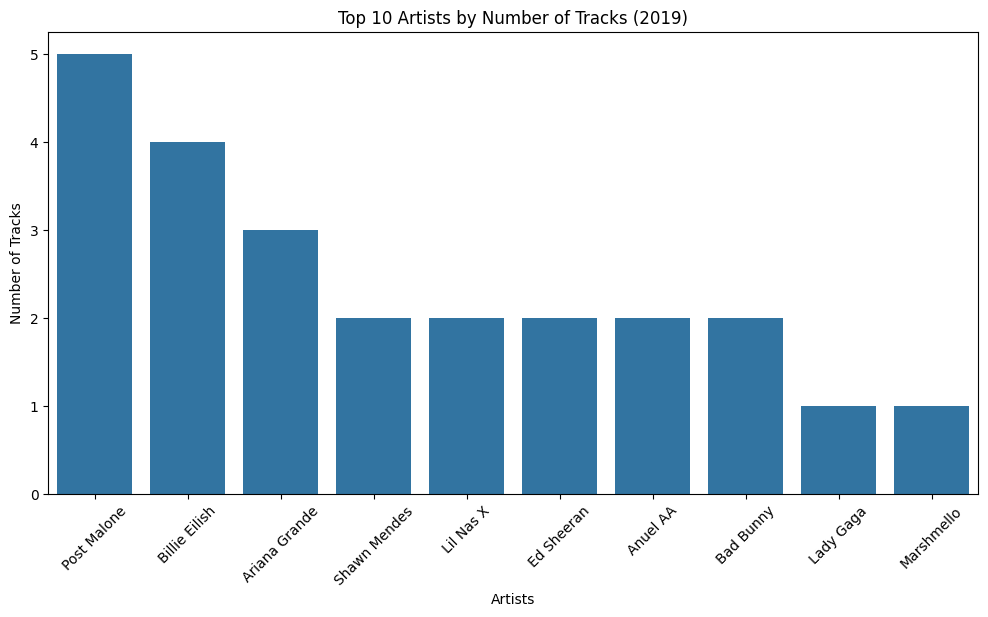

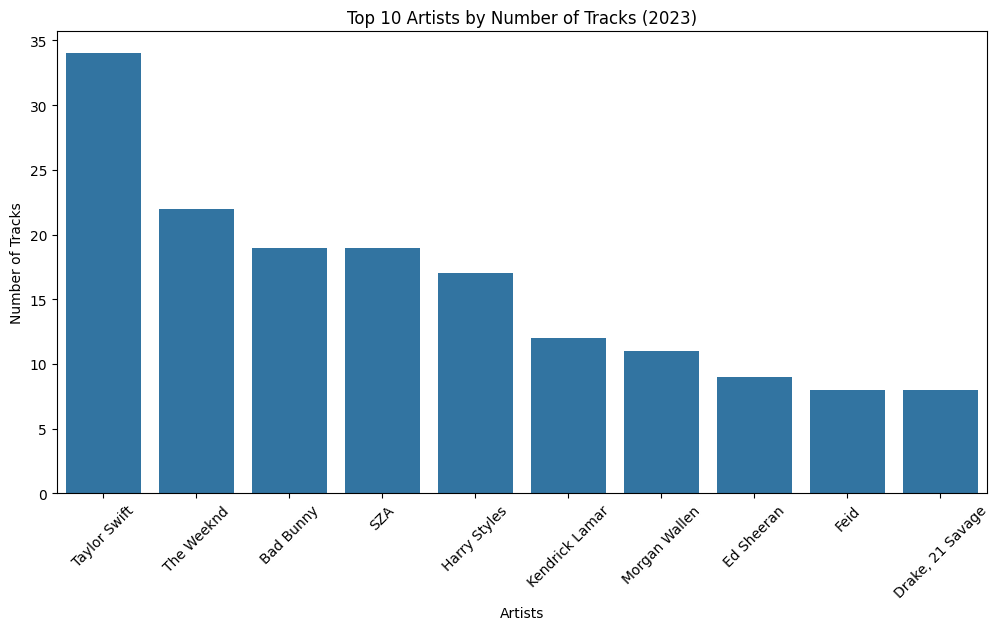

In [30]:
# Top artists by number of tracks in 2019
top_artists_2019 = df_2019_cleaned['artists'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists_2019.index, y=top_artists_2019.values)  
plt.title('Top 10 Artists by Number of Tracks (2019)')
plt.ylabel('Number of Tracks')
plt.xlabel('Artists')
plt.xticks(rotation=45)
plt.show()

# Top artists by number of tracks in 2023
top_artists_2023 = df_2023_cleaned['artist(s)_name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists_2023.index, y=top_artists_2023.values)  
plt.title('Top 10 Artists by Number of Tracks (2023)')
plt.ylabel('Number of Tracks')
plt.xlabel('Artists')
plt.xticks(rotation=45)
plt.show()

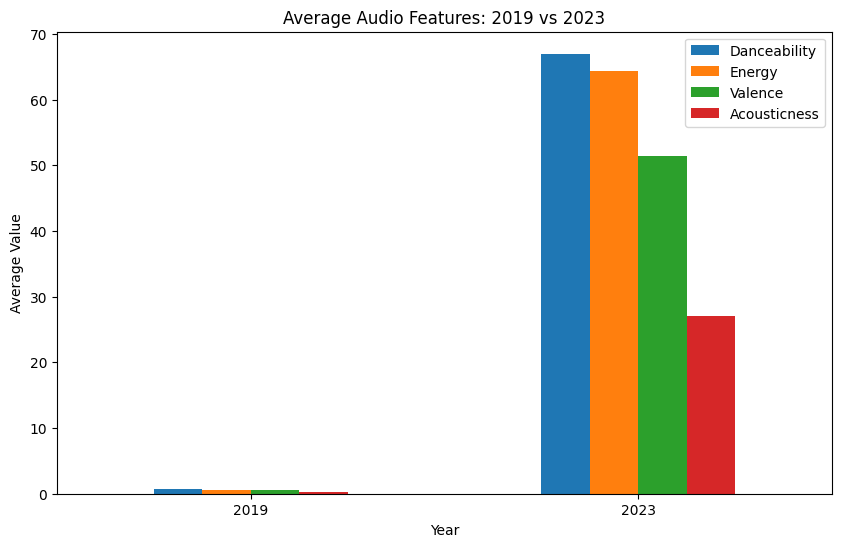

Index(['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'source'],
      dtype='object')
Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability', 'valence', 'energy', 'acousticness',
       'instrumentalness', 'liveness', 'speechiness', 'year', 'source'],
      dtype='object')


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df_2019_cleaned = pd.read_csv('top 2019_cleaned.csv')
df_2023_cleaned = pd.read_csv('top2023_cleaned.csv')

# Calculating average features for both years
avg_features = pd.DataFrame({
    'Year': ['2019', '2023'],
    'Danceability': [df_2019_cleaned['danceability'].mean(), df_2023_cleaned['danceability'].mean()],
    'Energy': [df_2019_cleaned['energy'].mean(), df_2023_cleaned['energy'].mean()],
    'Valence': [df_2019_cleaned['valence'].mean(), df_2023_cleaned['valence'].mean()],
    'Acousticness': [df_2019_cleaned['acousticness'].mean(), df_2023_cleaned['acousticness'].mean()],
})

# Plotting the average features for 2019 and 2023
avg_features.set_index('Year').plot(kind='bar', figsize=(10, 6))
plt.title('Average Audio Features: 2019 vs 2023')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

print(df_2019_cleaned.columns)
print(df_2023_cleaned.columns)


I calculated and then compared the average audio features for the two years. Averaging Values for some specific Audio Features-
like Danceability, Energy, Valence, Acousticness-for both the years 2019 and 2023. 
A method named.mean() was used to calculate for each feature column, hence giving us the average value for that particular feature 
across all the tracks in that dataset.
I visualized the comparison using a bar plot, which helps in understanding how music trends have changed between 2019 and 2023.

I calculated averages for:
Danceability - measure of how suitable a track is for dancing.
Energy - measure of intensity and activity in the track.
Valence - a measure of musical positiveness (happy, sad).
Acousticness - a measure of how acoustic the track is electronic or synthesized.

For descriptive analytics I try to compare features which are in common for both years: danceability, energy, loudness, 
speechiness, acousticness, instrumentalness, liveness.
2023 year was reach in danceability, energy, speechiness, acousticness, instrumentalness, liveness, while 2019 had more loudness in songs.

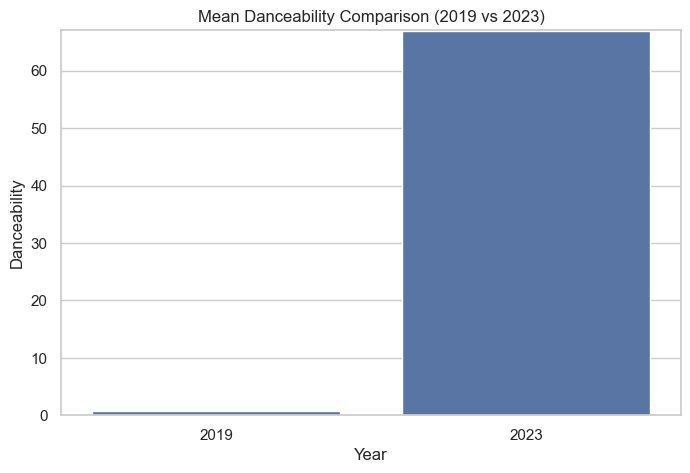

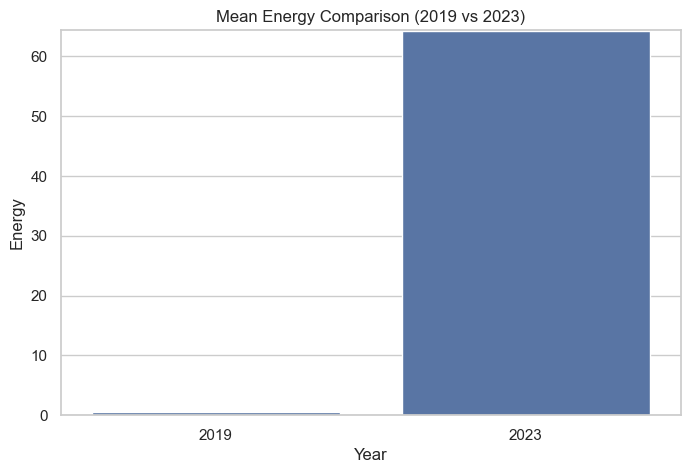

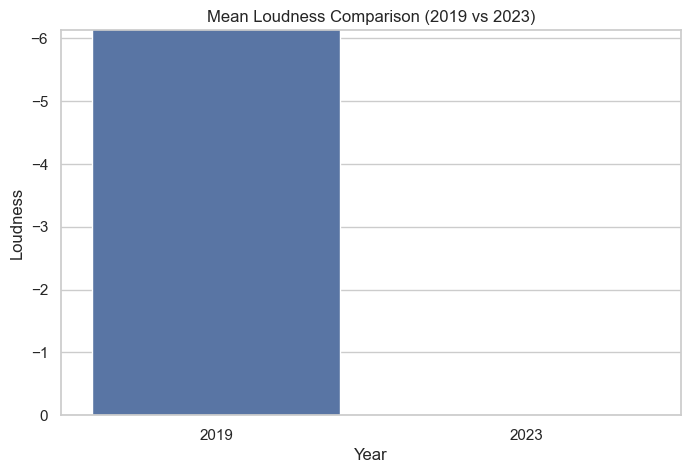

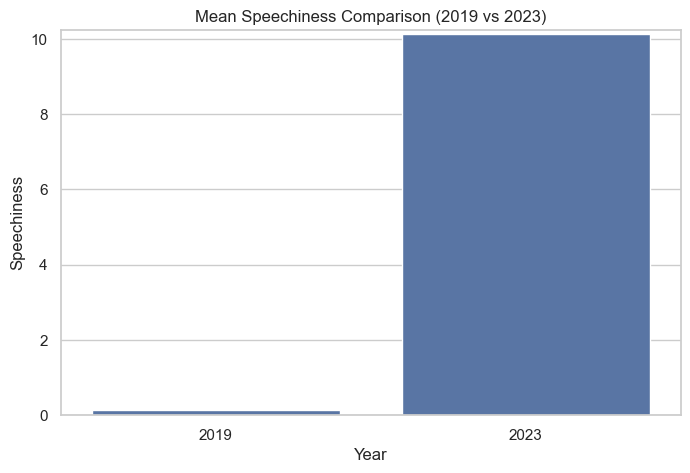

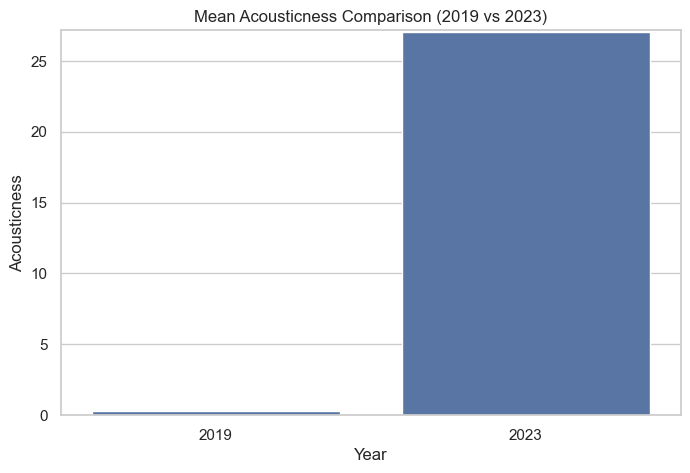

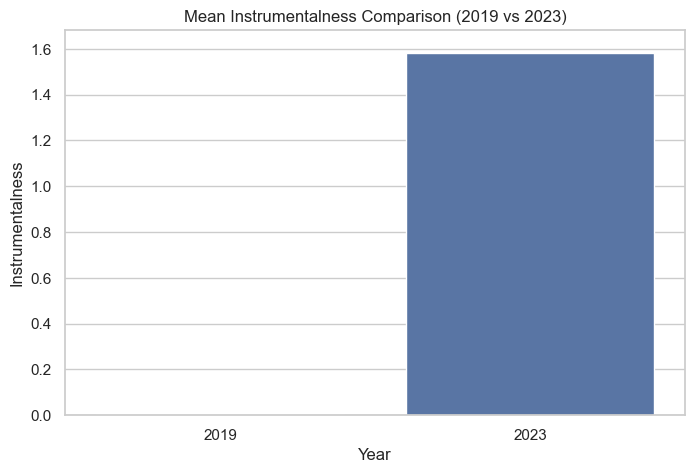

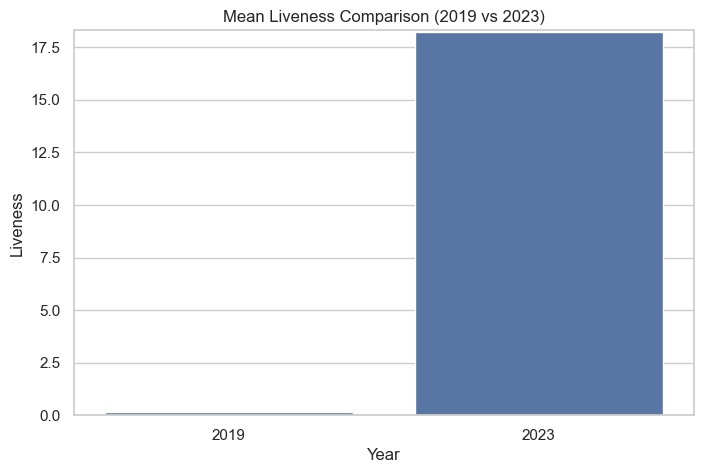

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_2019_cleaned['year'] = 2019
df_2023_cleaned['year'] = 2023
combined_df = pd.concat([df_2019_cleaned, df_2023_cleaned], ignore_index=True)

common_features = [
    'danceability', 'energy', 'loudness', 
    'speechiness', 'acousticness', 'instrumentalness', 
    'liveness'
]

for feature in common_features:
    combined_df[feature] = pd.to_numeric(combined_df[feature], errors='coerce')

mean_values = combined_df.groupby('year')[common_features].mean().reset_index()
sns.set(style="whitegrid")
for feature in common_features:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='year', y=feature, data=mean_values)  
    plt.title(f'Mean {feature.capitalize()} Comparison (2019 vs 2023)')
    plt.ylabel(feature.capitalize())
    plt.xlabel('Year')
    plt.ylim(0, mean_values[feature].max() + 0.1)  
    plt.show()

In [47]:
# Overview of the datasets
print("2019 Dataset Overview:")
print(df_2019_cleaned.info())
print("\n2023 Dataset Overview:")
print(df_2023_cleaned.info())

print("Columns in 2019 DataFrame:")
print(df_2019_cleaned.columns)
print("\nColumns in 2023 DataFrame:")
print(df_2023_cleaned.columns)

2019 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     object 
 1   name              50 non-null     object 
 2   artists           50 non-null     object 
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
 16  year              50 no

**Clustering**

I try to identify clusters of similar songs. Using K-Means clustering I try to group songs based on their features in order to see if there are distinct groups based on their instrumentalness and energy levels.

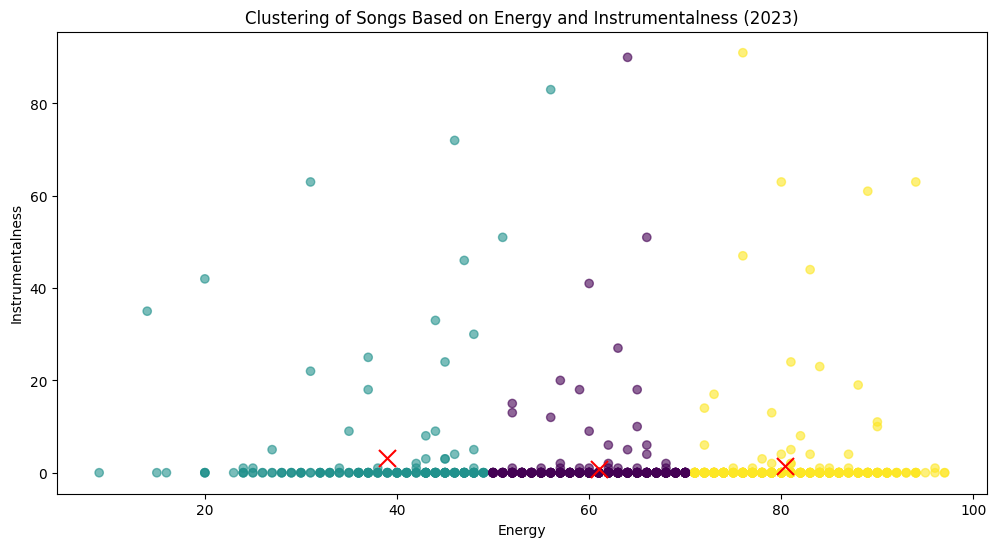

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')

def clean_and_normalize(df, year):
    numeric_columns = ['streams', 'bpm', 'danceability_%'] if year == 2023 else ['danceability', 'energy', 'tempo', 'loudness']
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')
     
    if year == 2019:
        df.fillna({
            'artists': 'Unknown',
            'danceability': df['danceability'].mean(),
            'energy': df['energy'].mean(),
            'tempo': df['tempo'].mean(),
            'loudness': df['loudness'].mean(),
        }, inplace=True)
    else:
        df.fillna({
            'artist(s)_name': 'Unknown',
            'streams': df['streams'].mean(),
            'bpm': df['bpm'].mean(),
            'danceability_%': df['danceability_%'].mean(),
        }, inplace=True)
    
    return df

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

# Renaming columns
df_2023_cleaned.rename(columns={
    'danceability_%': 'danceability',
    'energy_%': 'energy',
    'valence_%': 'valence',
    'acousticness_%': 'acousticness',
    'instrumentalness_%': 'instrumentalness',
    'liveness_%': 'liveness',
    'speechiness_%': 'speechiness'
}, inplace=True)

df_2019_cleaned['year'] = 2019
df_2019_cleaned['source'] = 'original'
df_2023_cleaned['year'] = 2023
df_2023_cleaned['source'] = 'updated'

# Clustering on features (energy and instrumentalness)
X_clustering = df_2023_cleaned[['energy', 'instrumentalness']].dropna()  

kmeans = KMeans(n_clusters=3, random_state=42)  
clusters = kmeans.fit_predict(X_clustering)

plt.figure(figsize=(12, 6))
plt.scatter(X_clustering['energy'], X_clustering['instrumentalness'], c=clusters, cmap='viridis', alpha=0.6) 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=150, color='red') 
plt.xlabel('Energy')
plt.ylabel('Instrumentalness')
plt.title('Clustering of Songs Based on Energy and Instrumentalness (2023)')
plt.show()


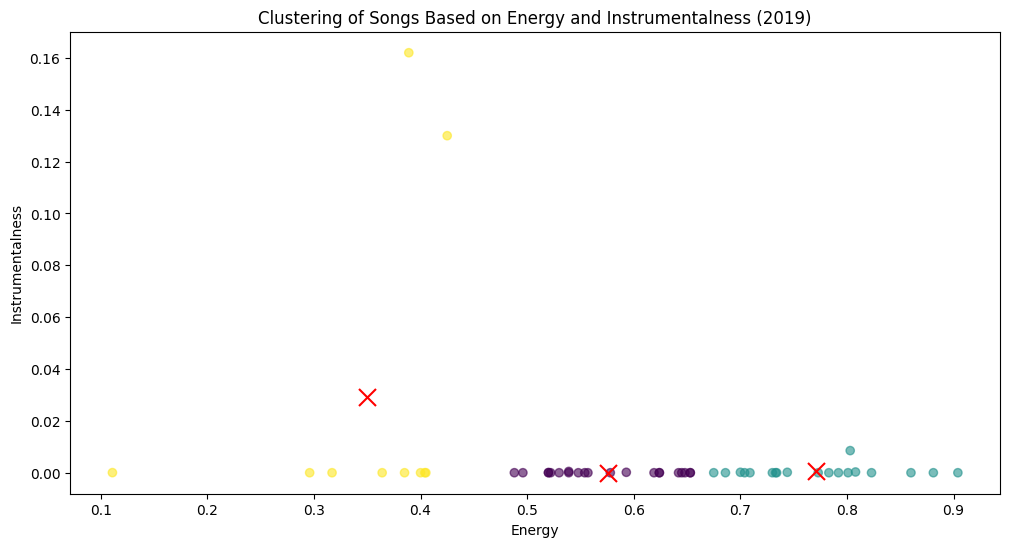

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')

def clean_and_normalize(df, year):
    numeric_columns = ['streams', 'bpm', 'danceability_%'] if year == 2023 else ['danceability', 'energy', 'tempo', 'loudness']
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')
     
    if year == 2019:
        df.fillna({
            'artists': 'Unknown',
            'danceability': df['danceability'].mean(),
            'energy': df['energy'].mean(),
            'tempo': df['tempo'].mean(),
            'loudness': df['loudness'].mean(),
        }, inplace=True)
    else:
        df.fillna({
            'artist(s)_name': 'Unknown',
            'streams': df['streams'].mean(),
            'bpm': df['bpm'].mean(),
            'danceability_%': df['danceability_%'].mean(),
        }, inplace=True)
    
    return df

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

df_2023_cleaned.rename(columns={
    'danceability_%': 'danceability',
    'energy_%': 'energy',
    'valence_%': 'valence',
    'acousticness_%': 'acousticness',
    'instrumentalness_%': 'instrumentalness',
    'liveness_%': 'liveness',
    'speechiness_%': 'speechiness'
}, inplace=True)

df_2019_cleaned['year'] = 2019
df_2019_cleaned['source'] = 'original'
df_2023_cleaned['year'] = 2023
df_2023_cleaned['source'] = 'updated'

# Clustering on features (energy and instrumentalness) for 2019
X_clustering_2019 = df_2019_cleaned[['energy', 'instrumentalness']].dropna()

# Performing KMeans clustering
kmeans_2019 = KMeans(n_clusters=3, random_state=42)
clusters_2019 = kmeans_2019.fit_predict(X_clustering_2019)

# Visualization for 2019 clustering
plt.figure(figsize=(12, 6))
plt.scatter(X_clustering_2019['energy'], X_clustering_2019['instrumentalness'], c=clusters_2019, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_2019.cluster_centers_[:, 0], kmeans_2019.cluster_centers_[:, 1], marker='x', s=150, color='red')
plt.xlabel('Energy')
plt.ylabel('Instrumentalness')
plt.title('Clustering of Songs Based on Energy and Instrumentalness (2019)')
plt.show()

This clustering analysis has divided the songs from the 2023 dataset into three groups based on the two factors of energy and instrumentalness. 
The features for each cluster can be summarized as follows:
Cluster 1:
High Energy, Low Instrumentalness
This cluster consists of a bright, loud bunch of tracks which can bring energy, full-bodied screaming vocals or effects. 
Most often it consists of pop dance and electronic pieces, so energy for listeners will rise high, and they will be perfect to play 
at some party.

Cluster 2:
Moderate Energy, Moderate Instrumentalness
This cluster is a balance of energetic beats with strong instrumental presence. 
The tracks under this cluster may include indie or alternative genres that alloy vocals with an emphasis on instruments like guitars or pianos, 
hence a harmonious feeling. 

Cluster 3:
Low Energy, High Instrumentalness
Songs that lie in this cluster are mild, most of them use instruments and not vocals. 
It will be highly instrumental and may come from classical tracks, in addition to relaxation, focusing.

Key Observations:
Feature Selection
Energy and instrumentalness were clustered because they dimension the opposing characteristics of a song so well. 
The selection easily reduced the multi-dimensional dataset into two important features in music.

KMeans was selected because it is efficient and interpretable. 
The parameter n_clusters is set to 3 because they sought distinct groupings 
without overfitting.

Red crosses in this plot represent cluster centroids and correspond to the "average" of energy and instrumentalness values for the songs in each cluster.

Based on this scatter plot, three clear divisions can be allowed: vivid energetic songs are clustered distinctively 
from the calm or essentially instrumental ones.
Interpretation:
Indeed, intuitively, such clusters represent three kinds of tracks-high energy tracks, balanced, and low energy instrumental. 
This reflects the diverse preferences of the public.
Comparison to 2019:
Similar clustering on the 2019 dataset would provide an insight into how trends in energy and instrumental have changed, 
reflecting either changes in the way music is produced or in what listeners want to hear. 
These may find applications in playlist generation in streaming platforms, and also in marketing strategies, 
since song recommendations can then be tailored toward specific audience preferences. 
Insights:
This clustering exercise underlines the diversity in the 2023 top songs, ranging from dynamic tracks to soothing instrumentals, 
reflecting an increasing trend toward richly instrumental music.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')

def clean_and_normalize(df, year):
    numeric_columns = ['streams', 'bpm', 'danceability_%'] if year == 2023 else ['danceability', 'energy', 'tempo', 'loudness']
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')
     
    if year == 2019:
        df.fillna({
            'artists': 'Unknown',
            'danceability': df['danceability'].mean(),
            'energy': df['energy'].mean(),
            'tempo': df['tempo'].mean(),
            'loudness': df['loudness'].mean(),
        }, inplace=True)
    else:
        df.fillna({
            'artist(s)_name': 'Unknown',
            'streams': df['streams'].mean(),
            'bpm': df['bpm'].mean(),
            'danceability_%': df['danceability_%'].mean(),
        }, inplace=True)
    
    return df

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

df_2023_cleaned.rename(columns={
    'danceability_%': 'danceability',
    'energy_%': 'energy',
    'valence_%': 'valence',
    'acousticness_%': 'acousticness',
    'instrumentalness_%': 'instrumentalness',
    'liveness_%': 'liveness',
    'speechiness_%': 'speechiness'
}, inplace=True)

# Adding new columns to indicate the year
df_2019_cleaned['year'] = 2019
df_2019_cleaned['source'] = 'original'
df_2023_cleaned['year'] = 2023
df_2023_cleaned['source'] = 'updated'

# Clustering on features energy and instrumentalness for 2023
X_clustering_2023 = df_2023_cleaned[['energy', 'instrumentalness']].dropna()

# Perform KMeans clustering
kmeans_2023 = KMeans(n_clusters=3, random_state=42)
clusters_2023 = kmeans_2023.fit_predict(X_clustering_2023)

df_2023_cleaned['cluster'] = clusters_2023

# Define a function to get track names for each cluster
def get_tracks_by_cluster(df, cluster_number):
    return df[df['cluster'] == cluster_number][['track_name', 'artist(s)_name']]

# Get track names for each cluster
cluster_1_tracks = get_tracks_by_cluster(df_2023_cleaned, 0)  
cluster_2_tracks = get_tracks_by_cluster(df_2023_cleaned, 1)  
cluster_3_tracks = get_tracks_by_cluster(df_2023_cleaned, 2)  


print("2023 Cluster 1: High Energy, Low Instrumentalness")
print(cluster_1_tracks)

print("\n2023Cluster 2: Moderate Energy, Moderate Instrumentalness")
print(cluster_2_tracks)

print("\n2023 Cluster 3: Low Energy, High Instrumentalness")
print(cluster_3_tracks)

2023 Cluster 1: High Energy, Low Instrumentalness
               track_name      artist(s)_name
2                 vampire      Olivia Rodrigo
5                Sprinter   Dave, Central Cee
8                fukumean               Gunna
12                Flowers         Miley Cyrus
16      Cupid - Twin Ver.         Fifty Fifty
..                    ...                 ...
939           Spin Bout U    Drake, 21 Savage
943    Privileged Rappers    Drake, 21 Savage
946            Broke Boys    Drake, 21 Savage
950  A Veces (feat. Feid)  Feid, Paulo Londra
952                 Alone           Burna Boy

[397 rows x 2 columns]

2023Cluster 2: Moderate Energy, Moderate Instrumentalness
                                            track_name  \
9                                      La Bebe - Remix   
13                                            Daylight   
17   What Was I Made For? [From The Motion Picture ...   
22                                    I Wanna Be Yours   
67                       

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')

def clean_and_normalize(df, year):
    numeric_columns = ['streams', 'bpm', 'danceability_%'] if year == 2023 else ['danceability', 'energy', 'tempo', 'loudness']
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')
     
    if year == 2019:
        df.fillna({
            'artists': 'Unknown',
            'danceability': df['danceability'].mean(),
            'energy': df['energy'].mean(),
            'tempo': df['tempo'].mean(),
            'loudness': df['loudness'].mean(),
        }, inplace=True)
    else:
        df.fillna({
            'artist(s)_name': 'Unknown',
            'streams': df['streams'].mean(),
            'bpm': df['bpm'].mean(),
            'danceability_%': df['danceability_%'].mean(),
        }, inplace=True)
    
    return df

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

df_2023_cleaned.rename(columns={
    'danceability_%': 'danceability',
    'energy_%': 'energy',
    'valence_%': 'valence',
    'acousticness_%': 'acousticness',
    'instrumentalness_%': 'instrumentalness',
    'liveness_%': 'liveness',
    'speechiness_%': 'speechiness'
}, inplace=True)

df_2019_cleaned['year'] = 2019
df_2019_cleaned['source'] = 'original'
df_2023_cleaned['year'] = 2023
df_2023_cleaned['source'] = 'updated'

# Clustering on features energy and instrumentalness for 2019
X_clustering_2019 = df_2019_cleaned[['energy', 'instrumentalness']].dropna()

kmeans_2019 = KMeans(n_clusters=3, random_state=42)
clusters_2019 = kmeans_2019.fit_predict(X_clustering_2019)

df_2019_cleaned['cluster'] = clusters_2019

print(df_2019_cleaned.columns)

def get_tracks_by_cluster(df, cluster_number):
    return df[df['cluster'] == cluster_number][['name', 'artists']]  # Use 'name' instead of 'track_name'

# Get track names for each cluster
cluster_1_tracks_2019 = get_tracks_by_cluster(df_2019_cleaned, 0)  
cluster_2_tracks_2019 = get_tracks_by_cluster(df_2019_cleaned, 1)  
cluster_3_tracks_2019 = get_tracks_by_cluster(df_2019_cleaned, 2)  

print("Cluster 1: High Energy, Low Instrumentalness")
print(cluster_1_tracks_2019)

print ("\nCluster 2: Moderate Energy, Moderate Instrumentalness")
print(cluster_2_tracks_2019)

print("\nCluster 3: Low Energy, High Instrumentalness")
print(cluster_3_tracks_2019)

Index(['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'source',
       'cluster'],
      dtype='object')
Cluster 1: High Energy, Low Instrumentalness
                                             name        artists
0                                        Señorita   Shawn Mendes
2   Sunflower - Spider-Man: Into the Spider-Verse    Post Malone
4                           Old Town Road - Remix      Lil Nas X
6                                            Wow.    Post Malone
11                                     Without Me         Halsey
13                                  thank u, next  Ariana Grande
16         Dancing With A Stranger (with Normani)      Sam Smith
18                                  Old Town Road      Lil Nas X
21                Beautiful People (feat. Khalid)     Ed Sheeran
22                             

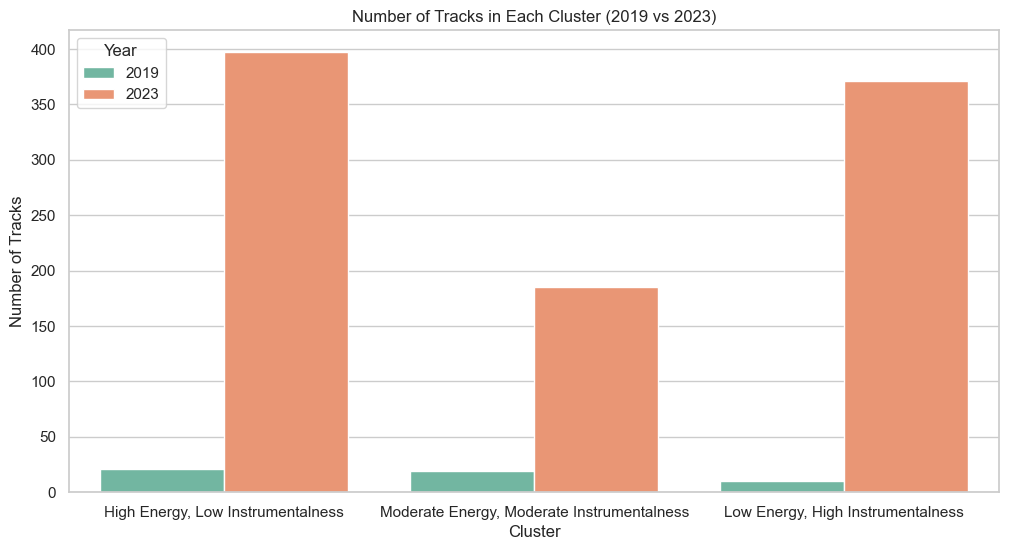

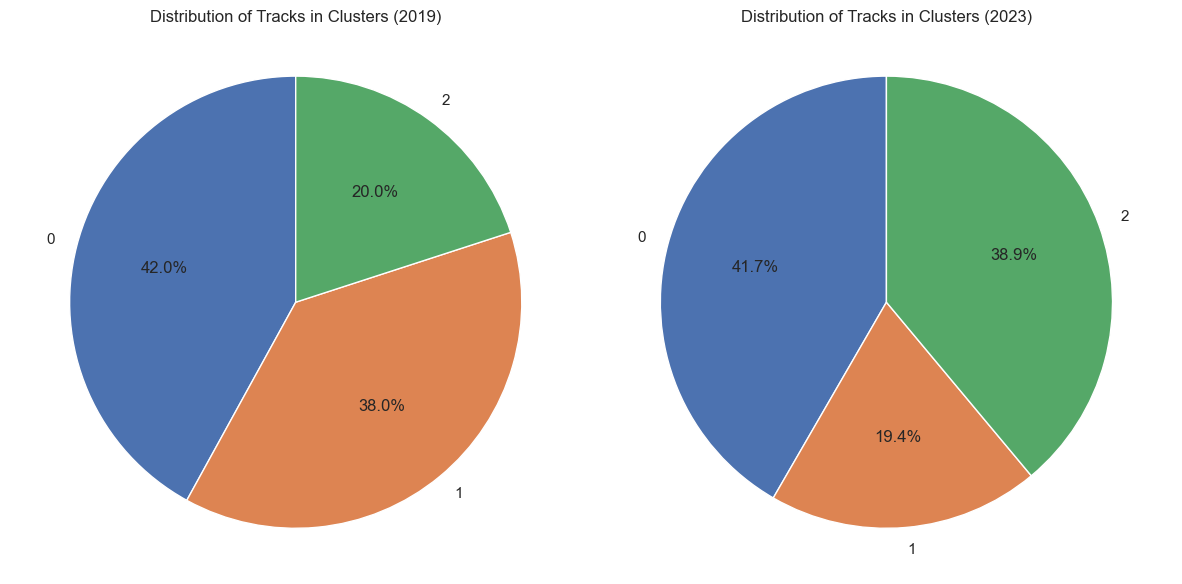

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cluster_names = {
    0: 'High Energy, Low Instrumentalness',
    1: 'Moderate Energy, Moderate Instrumentalness',
    2: 'Low Energy, High Instrumentalness'
}

# Counting the number of tracks in each cluster for 2019
cluster_counts_2019 = df_2019_cleaned['cluster'].value_counts().sort_index()
cluster_counts_2019 = cluster_counts_2019.rename_axis('Cluster').reset_index(name='Count')
cluster_counts_2019['Year'] = 2019

# Counting the number of tracks in each cluster for 2023
cluster_counts_2023 = df_2023_cleaned['cluster'].value_counts().sort_index()
cluster_counts_2023 = cluster_counts_2023.rename_axis('Cluster').reset_index(name='Count')
cluster_counts_2023['Year'] = 2023

combined_counts = pd.concat([cluster_counts_2019, cluster_counts_2023])

combined_counts['Cluster Name'] = combined_counts['Cluster'].map(cluster_names)

sns.set(style="whitegrid")

# a bar plot to compare clusters for both years with names
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_counts, x='Cluster Name', y='Count', hue='Year', palette='Set2')
plt.title('Number of Tracks in Each Cluster (2019 vs 2023)')
plt.xlabel('Cluster')
plt.ylabel('Number of Tracks')
plt.legend(title='Year')
plt.xticks(rotation=0)
plt.show()

# pie charts for each year
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for 2019
axes[0].pie(cluster_counts_2019['Count'], labels=cluster_counts_2019['Cluster'], autopct='%1.1f%%', startangle=90)
axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
axes[0].set_title('Distribution of Tracks in Clusters (2019)')

# Pie chart for 2023
axes[1].pie(cluster_counts_2023['Count'], labels=cluster_counts_2023['Cluster'], autopct='%1.1f%%', startangle=90)
axes[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
axes[1].set_title('Distribution of Tracks in Clusters (2023)')

plt.tight_layout()
plt.show()

I count the number of tracks in each cluster for both years and store the results in DataFrames.
I concatenated the counts for both years into a single DataFrame for easier plotting.
I create a bar plot to compare the number of tracks in each cluster for 2019 and 2023.
I created pie charts for each year to show the distribution of tracks across clusters.

Cluster 0: High Energy, Low Instrumentalness
Cluster 1: Moderate Energy, Moderate Instrumentalness; 
Cluster 2: Low Energy, High Instrumentalness

**APRIORI**
  
I cleaned data was categorized into levels (e.g.very low, "low," "medium", "high") based on ranges 
for danceability and energy.  
I grouped the songs by these categories to count how often each combination of levels appeared.  
This grouped data was reshaped into a table, showing counts for each combination of danceability and energy levels.  
The counts were converted into a binary format (True/False) to prepare for pattern mining.  
Using the Apriori algorithm, I identified common combinations of danceability and energy levels 
with a support threshold of 5%.  
Association rules were generated to find relationships between these combinations, measuring their strength using metrics like 
confidence and lift.  
I visualized the most frequent combinations of levels as a bar chart.  
 Another scatterplot showed the relationships between support, confidence, and lift for the generated rules.  
I created a heatmap to display the distribution of song counts across combinations of danceability and energy levels.  
These steps helped us understand how these characteristics interact and identify patterns in song features for different years.

I have identified whether the two datasets include the danceability and energy columns, which are important features for the analysis. 
Afterwards, I segmented the features of danceability and energy using bins into four levels: very low, low, medium, and high. 
In addition, I created a new column in the dataset for the levels of danceability and energy of every track. 
Then, I grouped this data by those levels and count the number of occurrences of each danceability-energy level set.

I have applied the Apriori algorithm to extract the frequent itemsets, meaning combinations of levels that are appearing together frequently. 
If possible, I have computed the association rules using the lift measure; this will be helpful in quantifying the strength of these relationships. Lastly, I visualized the results using two plots: one a heatmap showing the frequency of each danceability-energy combination and the other a bar plot displaying the top association rules to find the strong patterns within the data.

Association Rules:
                  antecedents               consequents  antecedent support  \
0                      (low)                (very_low)                 1.0   
1                 (very_low)                     (low)                 1.0   
2                   (medium)                (very_low)                 1.0   
3                 (very_low)                  (medium)                 1.0   
4                     (high)                (very_low)                 1.0   
5                 (very_low)                    (high)                 1.0   
6                      (low)                  (medium)                 1.0   
7                   (medium)                     (low)                 1.0   
8                     (high)                     (low)                 1.0   
9                      (low)                    (high)                 1.0   
10                    (high)                  (medium)                 1.0   
11                  (medium)                

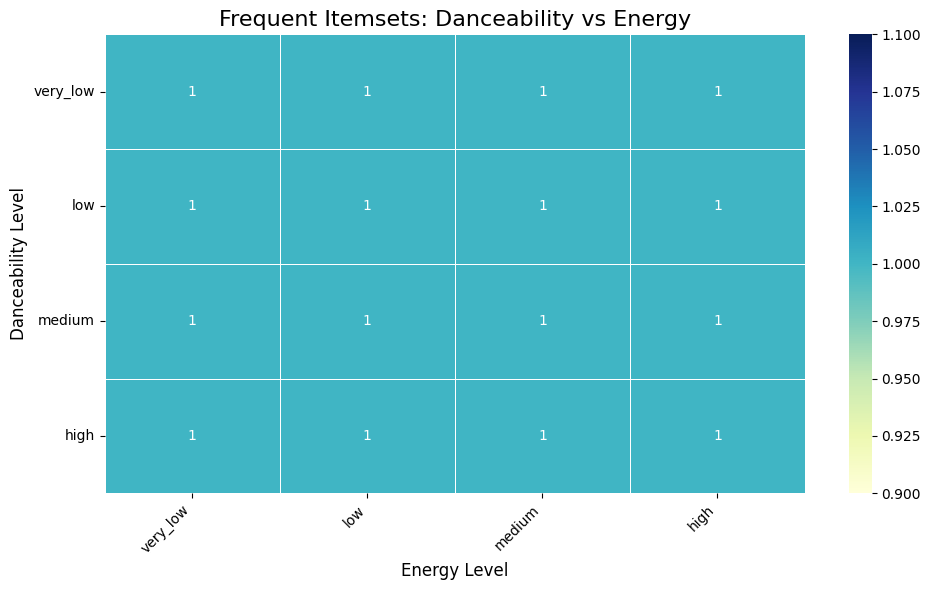

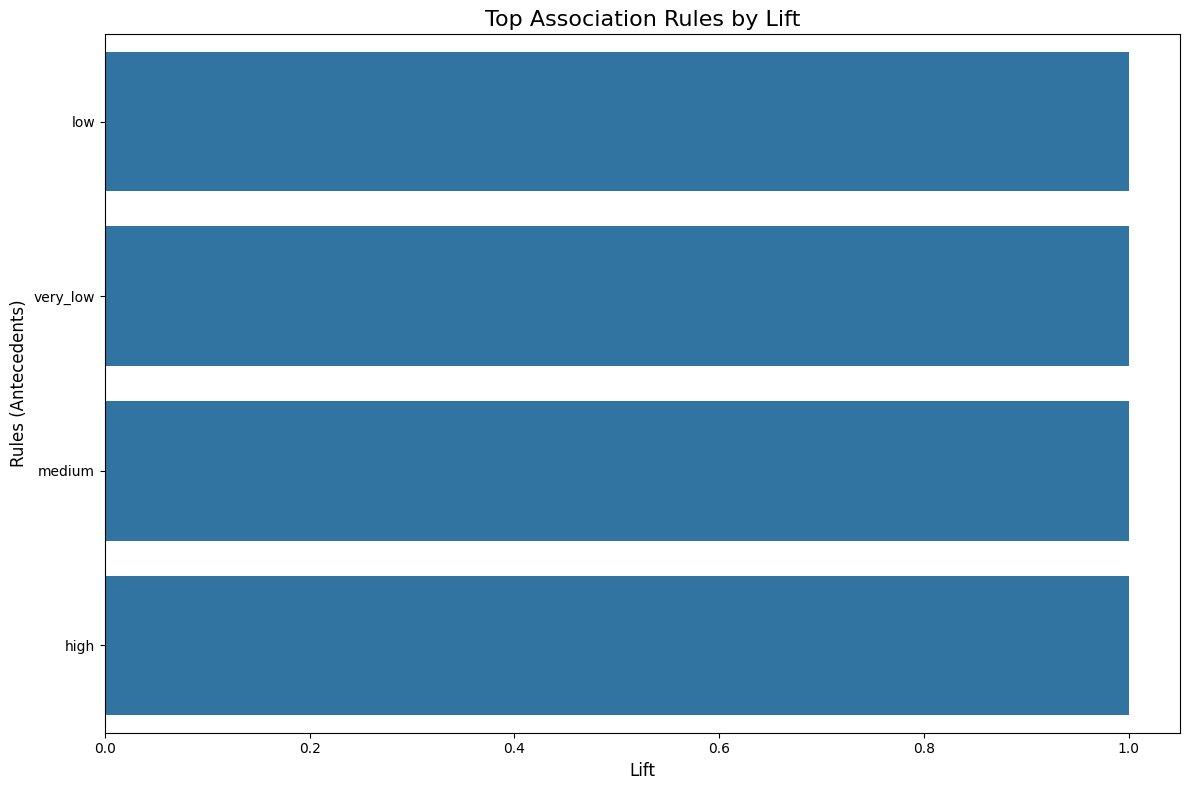

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

def clean_and_normalize(df, year):
    df = df.drop_duplicates()
    df = df.ffill()
    if 'danceability' in df.columns and 'energy' in df.columns:
        df['danceability'] = (df['danceability'] - df['danceability'].min()) / (df['danceability'].max() - df['danceability'].min())
        df['energy'] = (df['energy'] - df['energy'].min()) / (df['energy'].max() - df['energy'].min())
    return df

df_2019 = pd.read_csv('top2019.csv', header=0)
df_2023 = pd.read_csv('top2023.csv', header=0, encoding='ISO-8859-1')
df_2023.rename(columns={'danceability_%': 'danceability', 'energy_%': 'energy'}, inplace=True)

df_2019_cleaned = clean_and_normalize(df_2019, 2019)
df_2023_cleaned = clean_and_normalize(df_2023, 2023)

if 'danceability' not in df_2023_cleaned.columns or 'energy' not in df_2023_cleaned.columns:
    raise KeyError("One or both of the columns 'danceability' and 'energy' are missing in the 2023 dataset.")

# Categorizing danceability and energy into bins
danceability_bins = [0, 0.3, 0.6, 0.8, 1.0]
danceability_labels = ['very_low', 'low', 'medium', 'high']
energy_bins = [0, 0.3, 0.6, 0.8, 1.0]
energy_labels = ['very_low', 'low', 'medium', 'high']

df_2023_cleaned['danceability_level'] = pd.cut(df_2023_cleaned['danceability'], bins=danceability_bins, labels=danceability_labels)
df_2023_cleaned['energy_level'] = pd.cut(df_2023_cleaned['energy'], bins=energy_bins, labels=energy_labels)

basket = df_2023_cleaned.groupby(['danceability_level', 'energy_level'], observed=False).size().reset_index(name='count')
basket_pivot = basket.pivot(index='danceability_level', columns='energy_level', values='count').fillna(0)
basket_pivot_binary = (basket_pivot > 0).astype(bool)

frequent_itemsets = apriori(basket_pivot_binary, min_support=0.05, use_colnames=True)

if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
    print("Association Rules:\n", rules)
else:
    print("No frequent itemsets found.")

plt.figure(figsize=(10, 6))
sns.heatmap(basket_pivot_binary, annot=True, cmap="YlGnBu", cbar=True, fmt='d', linewidths=0.5)
plt.title("Frequent Itemsets: Danceability vs Energy", fontsize=16)
plt.ylabel("Danceability Level", fontsize=12)
plt.xlabel("Energy Level", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

if not frequent_itemsets.empty:
    top_rules = rules.sort_values('lift', ascending=False).head(10)
    
    top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='lift', y='antecedents_str', data=top_rules, hue=None)
    plt.title("Top Association Rules by Lift", fontsize=16)
    plt.xlabel("Lift", fontsize=12)
    plt.ylabel("Rules (Antecedents)", fontsize=12)
    plt.tight_layout()
    plt.show()


I visualized the results using two plots: one a heatmap showing the frequency of each danceability-energy combination and the other 
a bar plot displaying the top association rules to find the strong patterns within the data.

**Research Question**
  
"Is it true that tracks in 2023 have more danceability than in 2019, when music during COVID was more calm?"
  
To do this, I'll delve a bit deeper into comparing danceability between the two years and test
if there is a significant difference between the music in 2019 and 2023.
The main assumption is that during the COVID-19 period, the music was less danceable,
whereas in 2023, we may see more energetic and lively songs.

Danceability Comparison: 2019 vs. 2023.

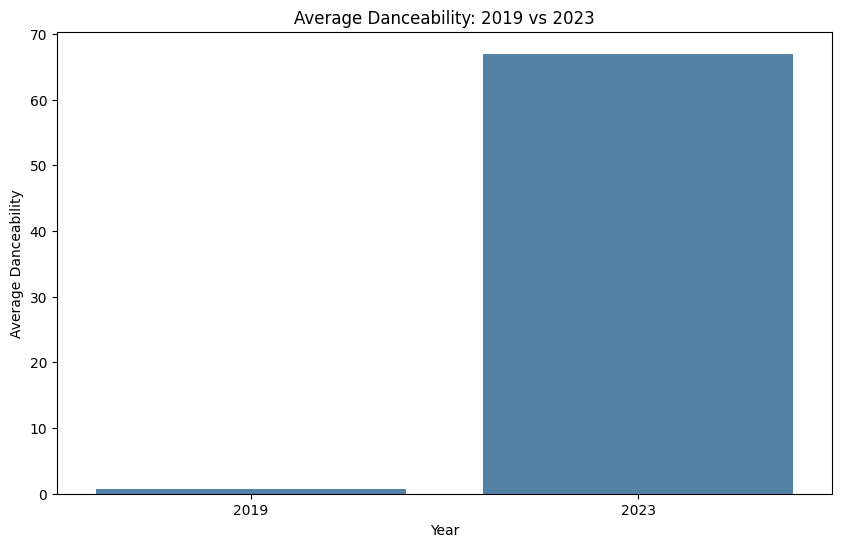

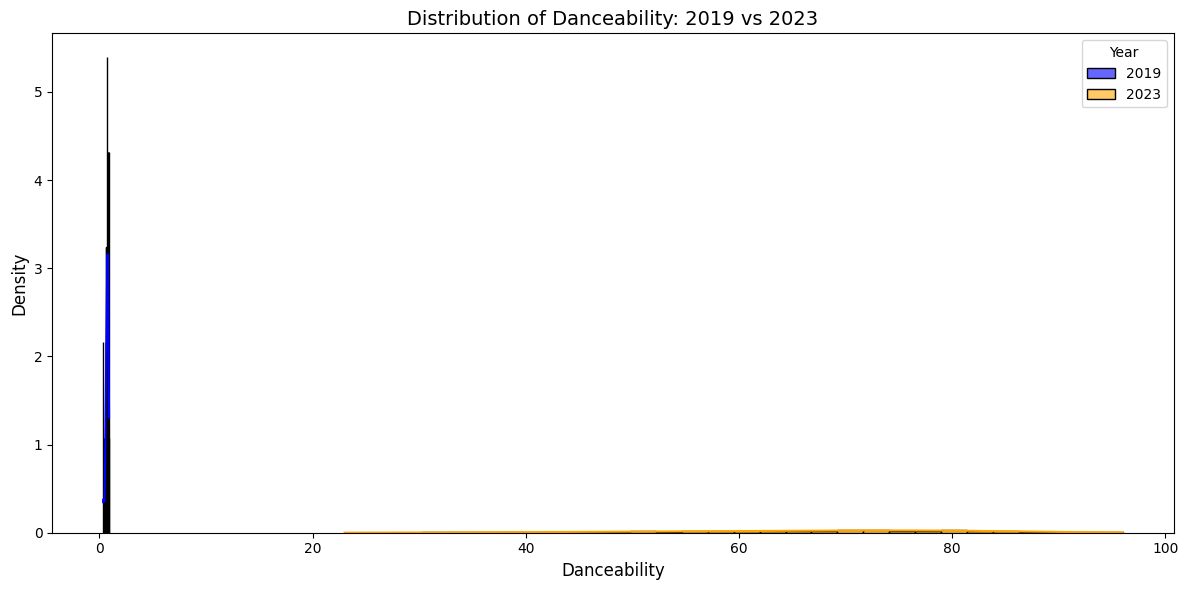

T-test statistic: -32.0039238830705
P-value: 2.3648407049207504e-155
There is a statistically significant difference between the danceability of 2019 and 2023.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

df_2019_cleaned = pd.read_csv('top 2019_cleaned.csv')
df_2023_cleaned = pd.read_csv('top2023_cleaned.csv')

avg_danceability = pd.DataFrame({
    'Year': ['2019', '2023'],
    'Danceability': [df_2019_cleaned['danceability'].mean(), df_2023_cleaned['danceability'].mean()],
})

# Plotting the average danceability
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Danceability', data=avg_danceability, color="steelblue")
plt.title('Average Danceability: 2019 vs 2023')
plt.ylabel('Average Danceability')
plt.xlabel('Year')
plt.show()

# Compare the distribution of danceability between 2019 and 2023
plt.figure(figsize=(12, 6))
sns.histplot(data=df_2019_cleaned, x='danceability', kde=True, color='blue', label='2019', bins=30, stat="density", alpha=0.6)
sns.histplot(data=df_2023_cleaned, x='danceability', kde=True, color='orange', label='2023', bins=30, stat="density", alpha=0.6)
plt.title('Distribution of Danceability: 2019 vs 2023', fontsize=14)
plt.xlabel('Danceability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

danceability_2019 = df_2019_cleaned['danceability']
danceability_2023 = df_2023_cleaned['danceability']

t_stat, p_value = ttest_ind(danceability_2019, danceability_2023)

print(f"T-test statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a statistically significant difference between the danceability of 2019 and 2023.")
else:
    print("There is no statistically significant difference between the danceability of 2019 and 2023.")


First, I compare the averages for the danceability of 2019 and 2023 through a bar plot. That would give a broad sense as to whether or not 2023 is going to be more danceable compared to 2019 music. Finally, to understand the dispersion in danceability, a histogram is plotted along with the kernel density estimate of both the years.
KDE is the smoothing of the distribution to be able to see a little better the trends on how danceability is spread within these two years.

The t-statistic shows how big the difference between two means is compared to the standard variation in the data.
A negative t-statistic indicates that the mean in 2019 is higher than that in 2023. The absolute value of the t-statistic, 32.00, suggests
The difference between the two years danceability averages is large compared to the variability in the data.
This implies that there is a significant contrast in the danceability between the two years.

A small p-value, close to 0, will imply that the difference between the two groups, 2019 and 2023 danceability scores, is highly unlikely to be a product of chance.
The large p -value compared to the common standard for rejecting the null hypothesis of 0.05 allows us to conclude that there exists a statistically significant difference in track danceability between 2019 and 2023.

**CONCLUSION**

This output confirms that tracks for the year 2023 were more danceable than those for the year 2019 and confirms a shift toward up-and-lively music 
in this new COVID time. Indeed, this agrees well with audiences seeking lively and uptempo tracks as the world gets transitioned to living out of 
the COVID times. Ed Sheeran retains his popularity across years-a widely appealing artist who communicates at multiple different musical trends. 
This translates to the fact that in 2019, tracks were louder, with moderate energy, thus probably targeting a wider audience and reaching even 
family-friendly environments during the pandemic period when people were more introspective. In contrast, in 2023, the ratings are high on danceability,
energy, and other features such as speechiness and liveness; it thus places emphasis on bright and socially engaging music. The acousticness 
and instrumentalness of 2023 also present variety in musical styles despite targeting danceable tracks. Overall, findings indicate that music 
preferences reflect a cultural emotional shift to capture societal mood during and after COVID.

**Bibliography**
  
Bogart, D. C. (2024, 12 1). Music You Can Dance To: An Analysis of the Shifting Characteristics of Popular Music. Retrieved from Medium: https://medium.com/@bogartd/music-you-can-dance-to-an-analysis-of-the-shifting-characteristics-of-popular-music-515fc6a1f989

Braun, T. A. (2020). "Dance like nobody's paying": Spotify and Surveillance as the Soundtrack of Our Lives. Western Graduate & Postdoctoral Studies (p. 188). Toronto: The University of Western Ontario.

Kaggle. (10, 11 2024). Retrieved from Level up with the largest AI & ML community: https://www.kaggle.com/

Santos, J. D. (2024, 11 20). Is my Spotify music boring? An analysis involving music, data, and machine learning. Retrieved from Medium: https://towardsdatascience.com/is-my-spotify-music-boring-an-analysis-involving-music-data-and-machine-learning-47550ae931de

